<a href="https://colab.research.google.com/github/SUPRAJ29DB/machine_learning_01/blob/main/support_vector_machine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [4]:
from google.colab import files
filename=files.upload()

Saving large_weather_prediction_dataset.csv to large_weather_prediction_dataset.csv


In [5]:
import io
filename1=next(iter(filename))
df=pd.read_csv(io.StringIO(filename[filename1].decode('utf-8')))
df.head()

,temperature,humidity,wind_speed,pressure,visibility,cloud_cover,weather
0,23.59,35.68,15.69,1018.76,5.16,65.02,Sunny
1,26.81,43.59,14.02,1018.01,9.64,36.48,Cloudy
2,26.58,7.11,20.04,1004.03,2.20,20.91,Sunny
3,52.01,82.53,5.17,997.28,13.12,67.27,Rainy
4,18.30,47.23,10.39,1035.68,13.96,34.13,Cloudy


In [6]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['weather']=le.fit_transform(df['weather'])
df

,temperature,humidity,wind_speed,pressure,visibility,cloud_cover,weather
0,23.59,35.68,15.69,1018.76,5.16,65.02,2
1,26.81,43.59,14.02,1018.01,9.64,36.48,0
2,26.58,7.11,20.04,1004.03,2.20,20.91,2
3,52.01,82.53,5.17,997.28,13.12,67.27,1
4,18.30,47.23,10.39,1035.68,13.96,34.13,0
...,...,...,...,...,...,...,...
149995,25.81,42.47,4.34,1029.28,13.59,50.93,1
149996,25.93,68.51,17.97,1019.10,7.45,70.79,0
149997,13.15,36.06,6.31,1032.78,9.20,22.99,1
149998,21.55,81.39,10.11,1008.13,4.17,0.00,1


In [7]:
x=df.drop(['weather'], axis=1)
y=df['weather']

In [8]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest=train_test_split(x, y, test_size=0.2, random_state=0)

In [9]:
from sklearn.preprocessing import StandardScaler
sc= StandardScaler()
q = sc.fit_transform(xtrain)
xtrain=sc.transform(xtrain)
xtest=sc.transform(xtest)

In [10]:
from sklearn.svm import SVC
classifier=SVC(kernel='linear', random_state=0, probability=True)
classifier.fit(xtrain, ytrain)

SVC(kernel='linear', probability=True, random_state=0)

In [11]:
ypred=classifier.predict(xtest)

In [12]:
from sklearn.metrics import *
cm=confusion_matrix(ytest, ypred)
print(cm)
print("Accuracy: ", accuracy_score(ytest, ypred))
print("Precision: ", precision_score(ytest, ypred, average='weighted'))
print("Recall: ", recall_score(ytest, ypred, average='weighted'))
print("F1 Score: ", f1_score(ytest, ypred, average='weighted'))
print("AUC: ", roc_auc_score(ytest, classifier.predict_proba(xtest), multi_class='ovr', average='weighted'))

[[6266 1359 2253]
 [2113 6939 1141]
 [1410 1375 7144]]
Accuracy:  0.6783
Precision:  0.6788712518746275
Recall:  0.6783
F1 Score:  0.6782138496878497
AUC:  0.843942699167336


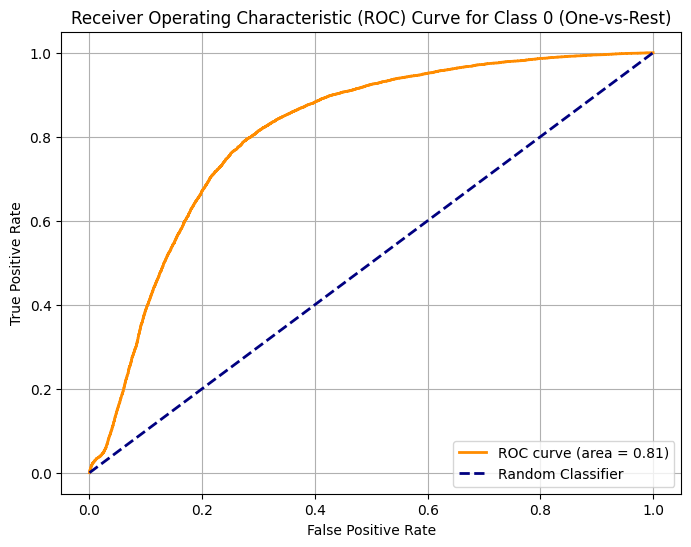

In [14]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get probabilities for each class from the logistic regression model
y_proba = classifier.predict_proba(xtest)

# Calculate ROC curve and AUC for class 0 (one-vs-rest)
# ytest == 0 creates a binary array where True means ytest is class 0, False otherwise.
fpr, tpr, _ = roc_curve(ytest == 0, y_proba[:, 0])
roc_auc = roc_auc_score(ytest == 0, y_proba[:, 0])

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Class 0 (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Using a Non-Linear SVC (RBF Kernel) on a Subsample

Given the computational cost of `SVC` with a non-linear kernel like 'rbf' on large datasets, I will create a subsample of the training data (`xtrain`, `ytrain`) to demonstrate its use. This will allow the model to train in a more reasonable timeframe.

Here, I'm taking a random sample of 10,000 data points from your original training set.

In [19]:
from sklearn.utils import resample

# Define the size of the subsample
subsample_size = 10000

# Create a subsample of the training data
xtrain_subsampled, ytrain_subsampled = resample(xtrain, ytrain, n_samples=subsample_size, random_state=42, stratify=ytrain)

print(f"Original training data size: {xtrain.shape[0]}")
print(f"Subsampled training data size: {xtrain_subsampled.shape[0]}")

Original training data size: 120000
Subsampled training data size: 10000


Now, let's train the `SVC` with an 'rbf' kernel on this subsampled data.

In [20]:
from sklearn.svm import SVC

# Initialize and train the SVC with 'rbf' kernel on the subsampled data
classifier_rbf = SVC(kernel='rbf', random_state=0, probability=True)
classifier_rbf.fit(xtrain_subsampled, ytrain_subsampled)

print("SVC with RBF kernel trained successfully on subsampled data.")

SVC with RBF kernel trained successfully on subsampled data.


Now that the `SVC` with 'rbf' kernel is trained on the subsampled data, let's evaluate its performance on the original test set. Note that the `classifier` variable was updated to use a linear kernel previously, and `classifier_rbf` is the new model with the rbf kernel on subsampled data.

In [21]:
ypred_rbf = classifier_rbf.predict(xtest)

cm_rbf = confusion_matrix(ytest, ypred_rbf)
print("Confusion Matrix (RBF Kernel on Subsampled Data):\n", cm_rbf)
print("Accuracy (RBF Kernel on Subsampled Data): ", accuracy_score(ytest, ypred_rbf))
print("Precision (RBF Kernel on Subsampled Data): ", precision_score(ytest, ypred_rbf, average='weighted'))
print("Recall (RBF Kernel on Subsampled Data): ", recall_score(ytest, ypred_rbf, average='weighted'))
print("F1 Score (RBF Kernel on Subsampled Data): ", f1_score(ytest, ypred_rbf, average='weighted'))

# Check if predict_proba is available and calculate AUC
if hasattr(classifier_rbf, 'predict_proba'):
    print("AUC (RBF Kernel on Subsampled Data): ", roc_auc_score(ytest, classifier_rbf.predict_proba(xtest), multi_class='ovr', average='weighted'))
else:
    print("AUC cannot be calculated: predict_proba is not available for this classifier.")

Confusion Matrix (RBF Kernel on Subsampled Data):
 [[9001  453  424]
 [1006 8873  314]
 [ 272  268 9389]]
Accuracy (RBF Kernel on Subsampled Data):  0.9087666666666666
Precision (RBF Kernel on Subsampled Data):  0.9094090138221921
Recall (RBF Kernel on Subsampled Data):  0.9087666666666666
F1 Score (RBF Kernel on Subsampled Data):  0.9086617018860537
AUC (RBF Kernel on Subsampled Data):  0.9794674379018447


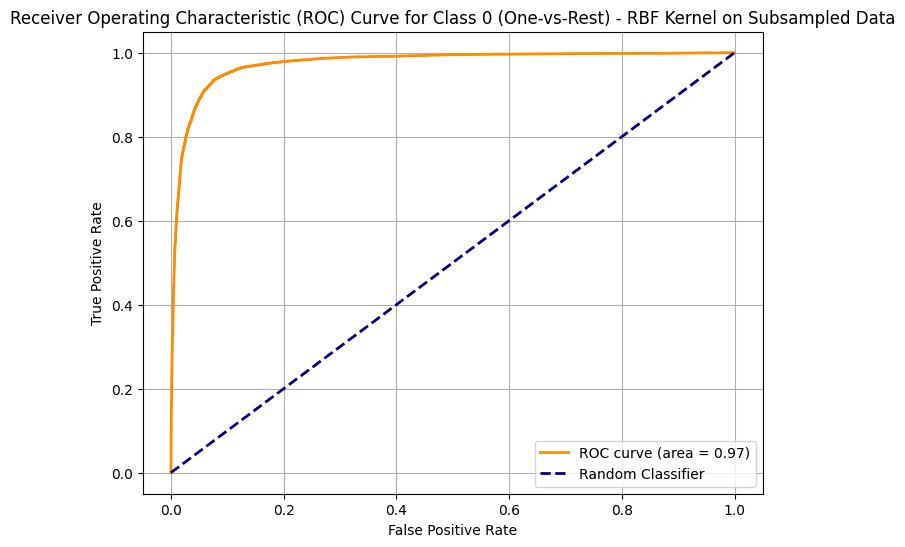

In [22]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get probabilities for each class from the RBF SVC model
y_proba_rbf = classifier_rbf.predict_proba(xtest)

# Calculate ROC curve and AUC for class 0 (one-vs-rest)
# ytest == 0 creates a binary array where True means ytest is class 0, False otherwise.
fpr_rbf, tpr_rbf, _ = roc_curve(ytest == 0, y_proba_rbf[:, 0])
roc_auc_rbf = roc_auc_score(ytest == 0, y_proba_rbf[:, 0])

plt.figure(figsize=(8, 6))
plt.plot(fpr_rbf, tpr_rbf, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_rbf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Class 0 (One-vs-Rest) - RBF Kernel on Subsampled Data')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()